In [22]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from skimage.filters import frangi, meijering, gabor
from scipy.ndimage import gaussian_filter, median_filter
from skimage.feature import hessian_matrix, hessian_matrix_eigvals
import matplotlib.pyplot as plt


In [23]:
def preprocess_octa(img):
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)
    norm_img = (img * 255).astype(np.uint8)

    img = cv2.bilateralFilter(norm_img, d=5, sigmaColor=15, sigmaSpace=15)
    img = img.astype(np.float32) / 255.0

    bg = cv2.GaussianBlur(img, (21, 21), 0)
    img = np.clip(img - 0.7 * bg, 0, 1)

    img = np.log1p(img * 5)
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)

    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    capC = clahe.apply((img * 255).astype(np.uint8))

    cap = meijering(img, sigmas=np.arange(1, 2.7, 1), black_ridges=False)
    cap = np.clip((cap - np.percentile(cap, 2)) /
                  (np.percentile(cap, 98) - np.percentile(cap, 2) + 1e-6),
                  0, 1)

    final = cv2.normalize((capC / 255) ** 0.8, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return final

In [24]:
def afficher_avant_apres(images_pairs):
    for i, (before, after) in enumerate(images_pairs):
        plt.figure(figsize=(10, 4))
        plt.suptitle(f"Image {i+1} : Avant / Après")

        plt.subplot(1, 2, 1)
        plt.imshow(before, cmap='gray')
        plt.title("Avant")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(after, cmap='gray')
        plt.title("Après")
        plt.axis("off")

        plt.show()


In [25]:
def decouper_en_4(img):
    h, w = img.shape
    assert h == 400 and w == 400

    patches = []
    patches.append(img[0:200, 0:200])
    patches.append(img[0:200, 200:400])
    patches.append(img[200:400, 0:200])
    patches.append(img[200:400, 200:400])

    return patches

In [26]:
def pad_200_to_256(img):
    pad_top = (256 - 200) // 2
    pad_bottom = 256 - 200 - pad_top

    padded = np.pad(img,
                    ((pad_top, pad_bottom), (pad_top, pad_bottom)),
                    mode='constant', constant_values=0)

    return padded

In [27]:
def afficher_4_patches(patches, title):
    plt.figure(figsize=(8, 8))
    plt.suptitle(title)

    for i in range(4):
        plt.subplot(2, 2, i+1)
        plt.imshow(patches[i], cmap='gray')
        plt.title(f"Patch {i+1}")
        plt.axis("off")

    plt.show()


Affichage Avant / Après...


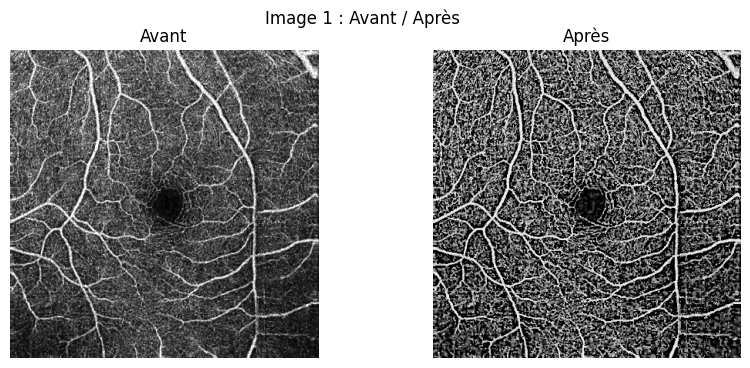

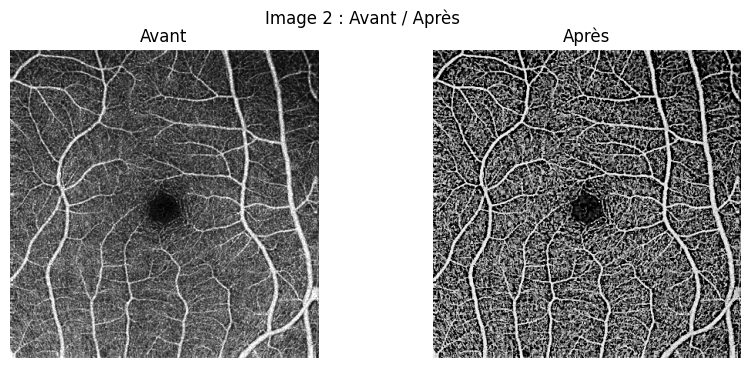

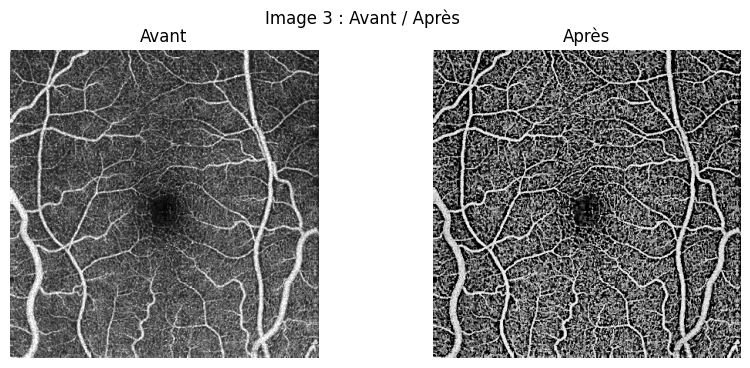


Découpage et padding des 3 premières images...

--- Image 1 ---


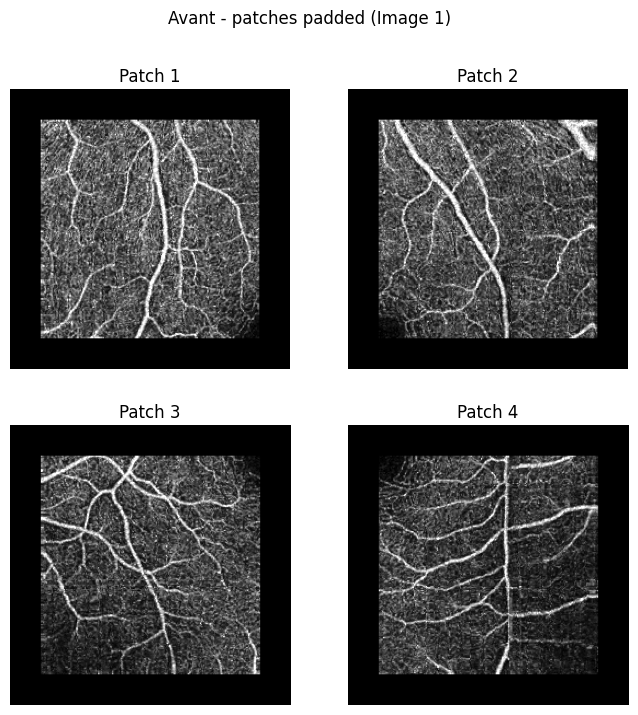

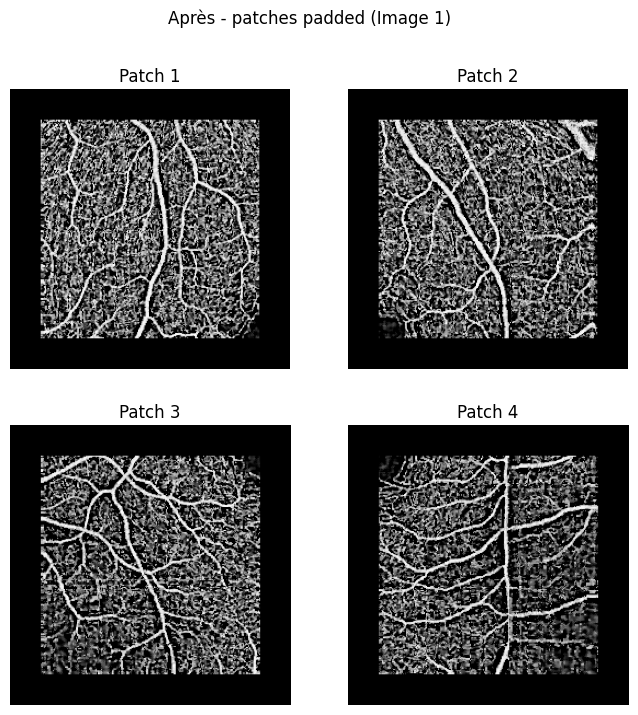

--- Image 2 ---


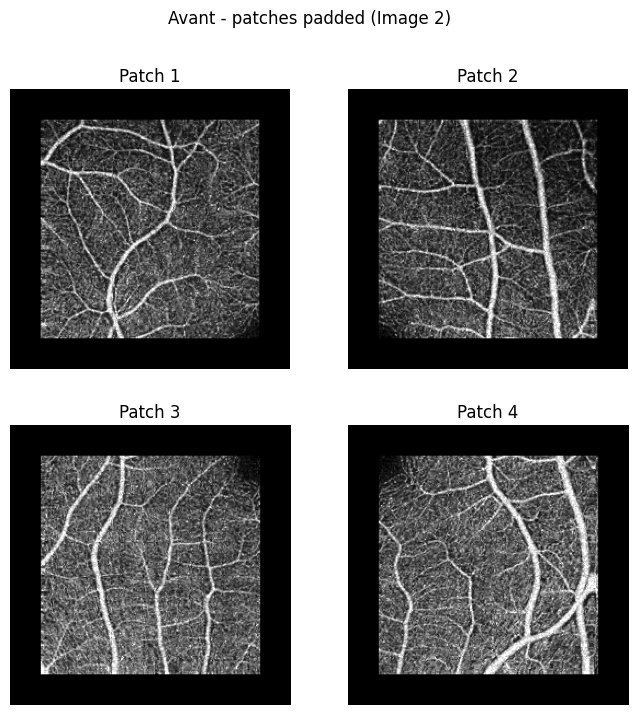

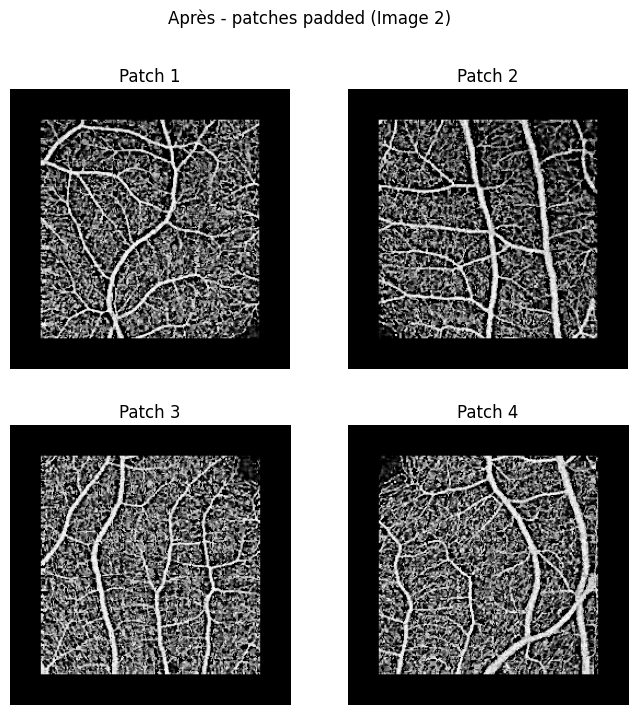

--- Image 3 ---


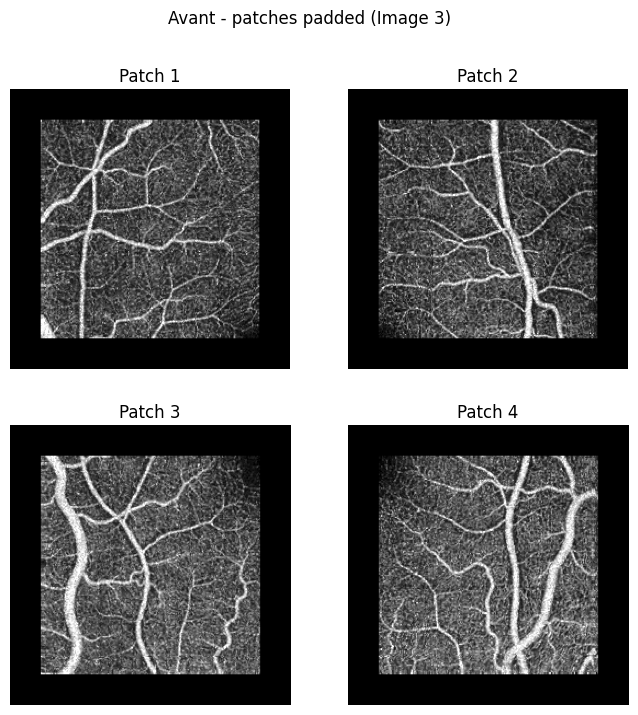

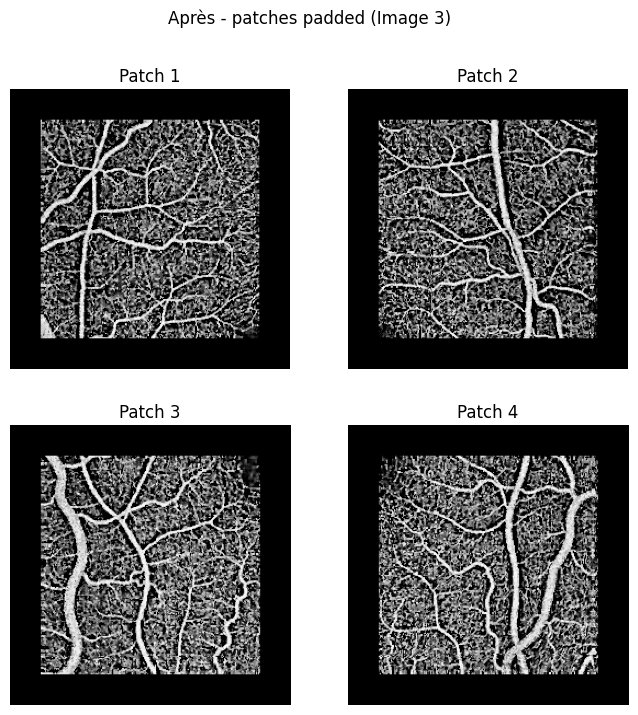

In [28]:
input_folder = "OCTA(ILM_OPL)/"

image_pairs = []
files = [f for f in os.listdir(input_folder)
         if f.lower().endswith((".png",".bmp",".jpg",".jpeg",".tif"))]

files = files[:3]

for file in files:
    before = cv2.imread(os.path.join(input_folder, file), cv2.IMREAD_GRAYSCALE)
    after = preprocess_octa(before.copy())
    image_pairs.append((before, after))

print("Affichage Avant / Après...")
afficher_avant_apres(image_pairs)

print("\nDécoupage et padding des 3 premières images...\n")

for i, (before, after) in enumerate(image_pairs):

    print(f"--- Image {i+1} ---")

    patches_before = decouper_en_4(before)
    patches_after = decouper_en_4(after)

    padded_before = [pad_200_to_256(p) for p in patches_before]
    padded_after = [pad_200_to_256(p) for p in patches_after]

    afficher_4_patches(padded_before, f"Avant - patches padded (Image {i+1})")
    afficher_4_patches(padded_after, f"Après - patches padded (Image {i+1})")
